# 第4章 学习更多图表和定制化

## 4.2 设置坐标轴标签的透明度和大小

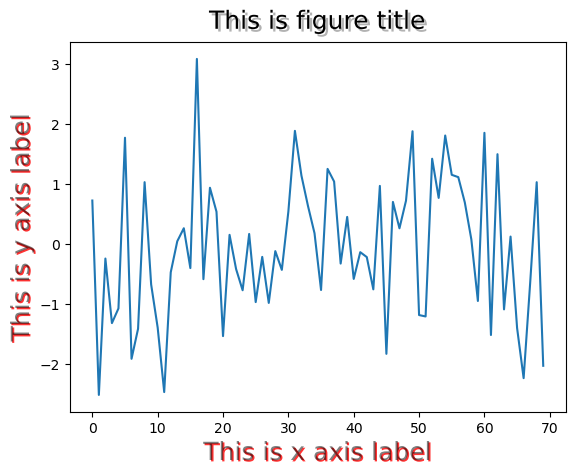

In [5]:
import matplotlib.pyplot as plt
from matplotlib import patheffects
import numpy as np

data = np.random.randn(70)
fontsize = 18
plt.plot(data)

title = "This is figure title"
x_label = "This is x axis label"
y_label = "This is y axis label"
title_text_obj = plt.title(title, fontsize=fontsize, verticalalignment='bottom')
title_text_obj.set_path_effects([patheffects.withSimplePatchShadow()])

# offset_xy -- set the 'angle' of the shadow
# shadow_rgbFace -- set the color of the shadow
# patch_alpha -- setup the transparency of the shadow
offset_xy = (1, -1)
rgbRed = (1.0,0.0,0.0)
alpha = 0.8

# customize shadow properties
pe = patheffects.withSimplePatchShadow(offset = offset_xy,
                                       shadow_rgbFace = rgbRed,
                                       alpha = alpha)

# apply them to the xaxis and yaxis labels
xlabel_obj = plt.xlabel(x_label, fontsize=fontsize, alpha=0.5)
xlabel_obj.set_path_effects([pe])

ylabel_obj = plt.ylabel(y_label, fontsize=fontsize, alpha=0.5)
ylabel_obj.set_path_effects([pe])

plt.show()

## 4.3 为图表线条添加阴影

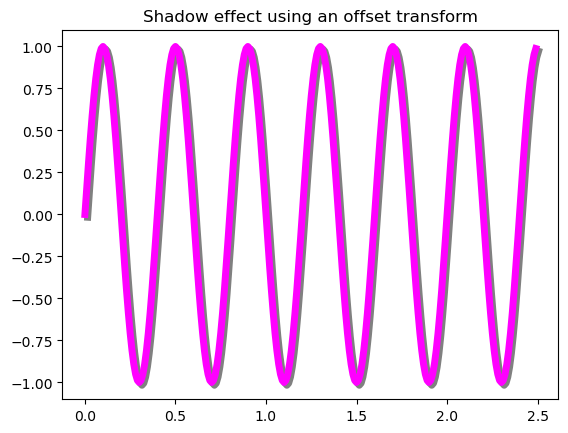

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms

def setup(layout=None):
    assert layout is not None
    fig = plt.figure()
    ax = fig.add_subplot(layout)
    return fig, ax

def get_signal():
    t = np.arange(0., 2.5, 0.01)
    s = np.sin(5 * np.pi * t)
    return t, s

def plot_signal(axes, t, s):
    line, = axes.plot(t, s, linewidth=5, color='magenta')
    return line
    
def make_shadow(fig, axes, line, t, s):
    delta = 2 / 72. # how many points to move the shadow
    offset = transforms.ScaledTranslation(delta, -delta,
    fig.dpi_scale_trans)
    offset_transform = axes.transData + offset
    
    # We plot the same data, but now using offset transform
    # zorder -- to render it below the line
    axes.plot(t, s, linewidth=5, color='gray',
              transform=offset_transform,
              zorder=0.5 * line.get_zorder())

if __name__ == "__main__":
    fig, axes = setup(111)
    t, s = get_signal()
    line = plot_signal(axes, t, s)
    make_shadow(fig, axes, line, t, s)
    axes.set_title('Shadow effect using an offset transform')
    plt.show()

## 4.4 向图表添加数据表

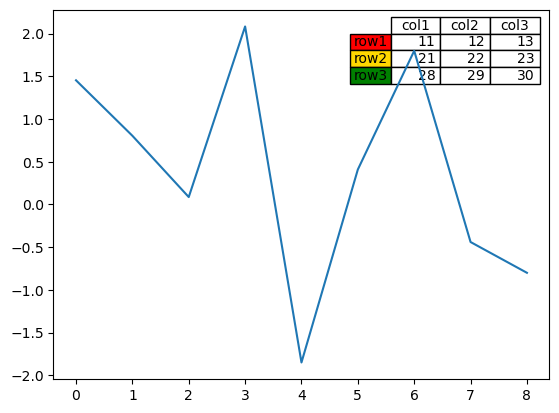

In [9]:
import matplotlib.pylab as plt
import numpy as np

plt.figure()
ax = plt.gca()
y = np.random.randn(9)

col_labels = ['col1','col2','col3']
row_labels = ['row1','row2','row3']
table_vals = [[11, 12, 13], [21, 22, 23], [28, 29, 30]]
row_colors = ['red', 'gold', 'green']
my_table = plt.table(cellText=table_vals,
                     colWidths=[0.1] * 3,
                     rowLabels=row_labels,
                     colLabels=col_labels,
                     rowColours=row_colors,
                     loc='upper right')
plt.plot(y)
plt.show()

## 4.5 使用子区（subplots）

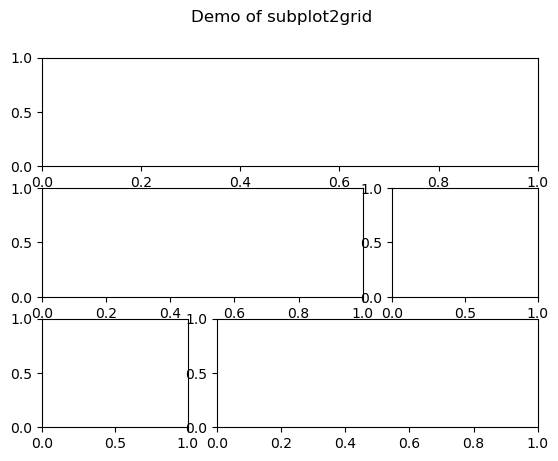

In [10]:
import matplotlib.pyplot as plt

plt.figure(0)
axes1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)
axes2 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
axes3 = plt.subplot2grid((3, 3), (1, 2))
axes4 = plt.subplot2grid((3, 3), (2, 0))
axes5 = plt.subplot2grid((3, 3), (2, 1), colspan=2)

# tidy up tick labels size
all_axes = plt.gcf().axes
for ax in all_axes:
    for ticklabel in ax.get_xticklabels() + ax.get_yticklabels():
        ticklabel.set_fontsize(10)

plt.suptitle("Demo of subplot2grid")
plt.show()

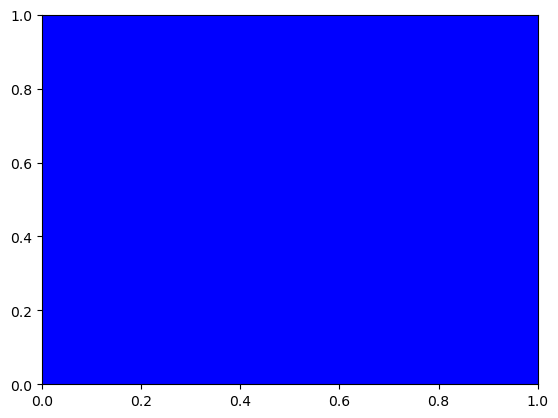

In [14]:
import matplotlib.pyplot as plt
fig = plt.figure()
axes = fig.add_subplot(111)
rectangle = axes.patch
rectangle.set_facecolor('blue')

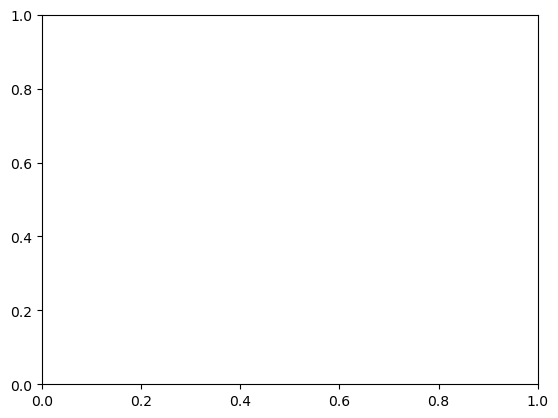

In [16]:
import matplotlib
import matplotlib.pyplot as plt

fig = plt.figure()
axes = fig.add_subplot(111)
rect = matplotlib.patches.Rectangle((1,1), width=6, height=12)
axes.add_patch(rect)
# we have to manually force a figure draw
axes.figure.canvas.draw()

## 4.6 定制化网格

In [18]:
import matplotlib.pyplot as plt

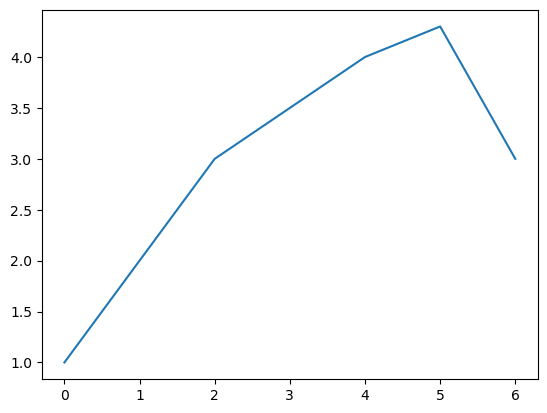

In [19]:
plt.plot([1,2,3,3.5,4,4.3,3])

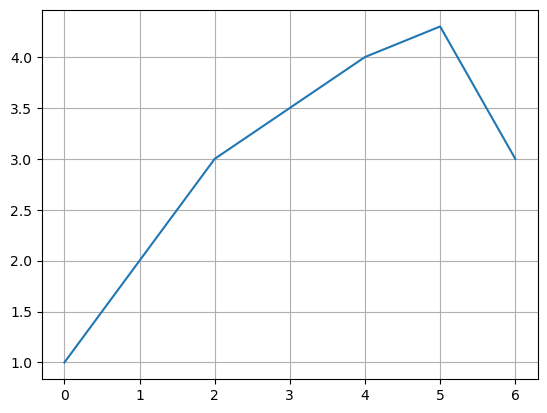

In [21]:
plt.plot([1,2,3,3.5,4,4.3,3])
plt.grid()

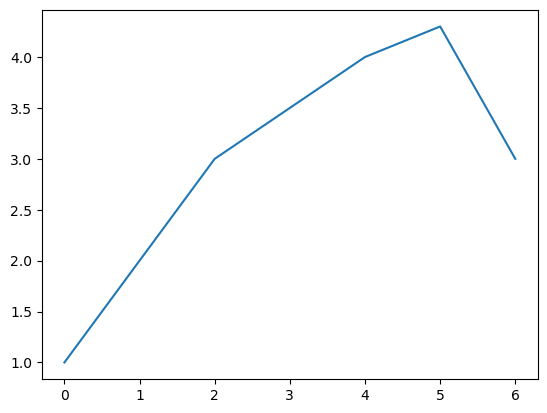

In [23]:
plt.plot([1,2,3,3.5,4,4.3,3])
plt.grid()
plt.grid()

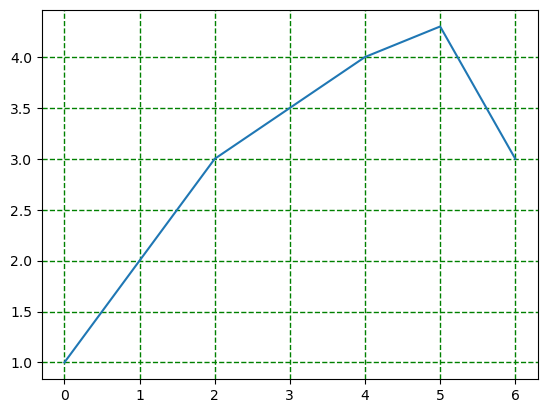

In [24]:
plt.plot([1,2,3,3.5,4,4.3,3])
ax = plt.gca()
ax.grid(color='g', linestyle='--', linewidth=1)

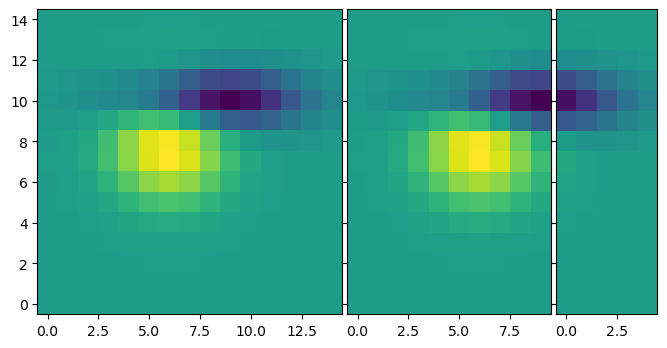

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib.cbook import get_sample_data

def get_demo_image():
    f = get_sample_data("axes_grid/bivariate_normal.npy",
                        asfileobj=False)
    # z is a numpy array of 15x15
    Z = np.load(f)
    return Z, (-3, 4, -4, 3)
    
def get_grid(fig=None, layout=None, nrows_ncols=None):
    assert fig is not None
    assert layout is not None
    assert nrows_ncols is not None
    grid = ImageGrid(fig, layout, nrows_ncols=nrows_ncols,
                     axes_pad=0.05, label_mode="L")
    return grid
    
def load_images_to_grid(grid, Z, *images):
    min, max = Z.min(), Z.max()
    for i, image in enumerate(images):
        axes = grid[i]
        axes.imshow(image, origin="lower", vmin=min, vmax=max,
                    interpolation="nearest")
        
if __name__ == "__main__":
    fig = plt.figure(1, (8, 6))
    grid = get_grid(fig, 111, (1, 3))
    Z, extent = get_demo_image()

    # Slice image
    image1 = Z
    image2 = Z[:, :10]
    image3 = Z[:, 10:]

    load_images_to_grid(grid, Z, image1, image2, image3)

    plt.draw()
    plt.show()

## 4.7 创建等高线图

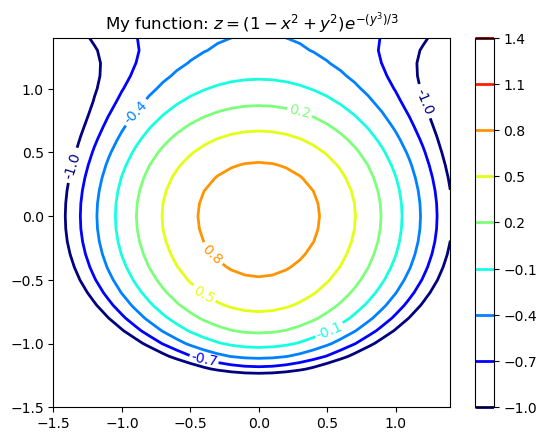

In [33]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def process_signals(x, y):
    return (1 - (x ** 2 + y ** 2)) * np.exp(-y ** 3 / 3)

x = np.arange(-1.5, 1.5, 0.1)
y = np.arange(-1.5, 1.5, 0.1)

# Make grids of points
X, Y = np.meshgrid(x, y)
Z = process_signals(X, Y)

# Number of isolines
N = np.arange(-1, 1.5, 0.3)

# adding the Contour lines with labels
CS = plt.contour(X, Y, Z, N, linewidths=2, cmap=mpl.cm.jet)

plt.clabel(CS, inline=True, fmt='%1.1f', fontsize=10)
plt.colorbar(CS)

plt.title('My function: $z=(1-x^2+y^2) e^{-(y^3)/3}$')
plt.show()

## 4.8 填充图表底层区域

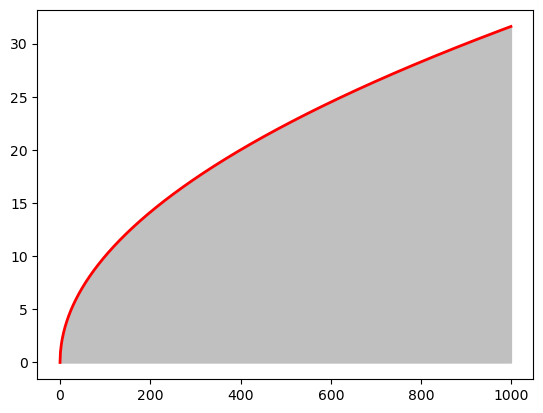

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

t = range(1000)
y = [sqrt(i) for i in t]

plt.plot(t, y, color='red', lw=2)
plt.fill_between(t, y, color='silver')
plt.show()

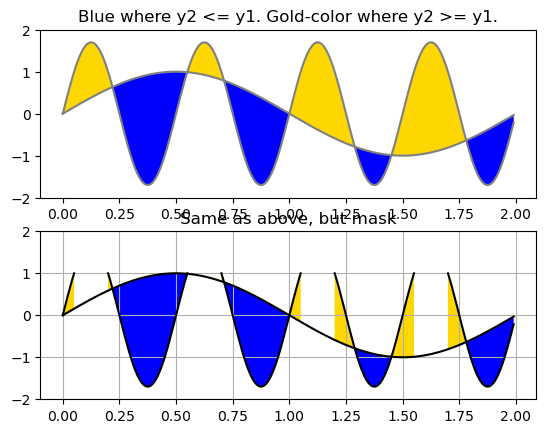

In [35]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0.0, 2, 0.01)
y1 = np.sin(np.pi*x)
y2 = 1.7*np.sin(4*np.pi*x)

fig = plt.figure()
axes1 = fig.add_subplot(211)
axes1.plot(x, y1, x, y2, color='grey')
axes1.fill_between(x, y1, y2, where=y2<=y1, facecolor='blue',
                   interpolate=True)
axes1.fill_between(x, y1, y2, where=y2>=y1, facecolor='gold',
                   interpolate=True)
axes1.set_title('Blue where y2 <= y1. Gold-color where y2 >= y1.')
axes1.set_ylim(-2,2)

# Mask values in y2 with value greater than 1.0
y2 = np.ma.masked_greater(y2, 1.0)
axes2 = fig.add_subplot(212, sharex=axes1)
axes2.plot(x, y1, x, y2, color='black')
axes2.fill_between(x, y1, y2, where=y2<=y1, facecolor='blue',
                   interpolate=True)
axes2.fill_between(x, y1, y2, where=y2>=y1, facecolor='gold',
                   interpolate=True)
axes2.set_title('Same as above, but mask')
axes2.set_ylim(-2,2)
axes2.grid('on')
plt.show()

## 4.9 绘制极线图

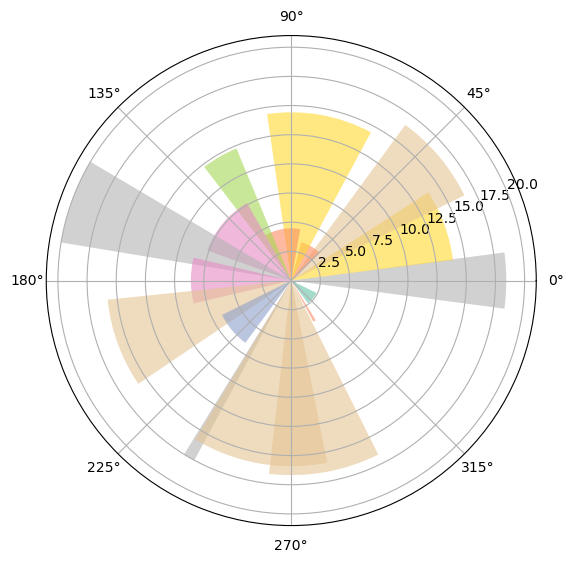

In [45]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

figsize = 7
colormap = lambda r: cm.Set2(r / 20.)
N = 18 # number of bars

fig = plt.figure(figsize=(figsize,figsize))
ax = fig.add_axes([0.2, 0.2, 0.7, 0.7], polar=True)

theta = np.arange(0.0, 2 * np.pi, 2 * np.pi/N)
radii = 20 * np.random.rand(N)
width = np.pi / 4 * np.random.rand(N)
bars = ax.bar(theta, radii, width=width, bottom=0.0)
for r, bar in zip(radii, bars):
    bar.set_facecolor(colormap(r))
    bar.set_alpha(0.6)

plt.show()

## 4.10 使用极线条可视化文件系统树

In [47]:
import os
def get_directories(path):
    dirs = set()
    for dirpath, dirnames, filenames in os.walk(path):
        dirs = set([os.path.join(dirpath, x) for x in dirnames])
        break # we just want the first one
    return dirs

dirs = get_directories('/home/hexu/git')
print(dirs)

{'/home/hexu/git/Computer.Graphics.Using.OpenGL', '/home/hexu/git/prog_pi_ed3', '/home/hexu/git/system-programming-examples', '/home/hexu/git/.ipynb_checkpoints', '/home/hexu/git/Reimplement.Of.Cpp.Standard.Library', '/home/hexu/git/sql-scripts-examples', '/home/hexu/git/Learning.Robot.Programming.With.Ros', '/home/hexu/git/Programming.The.Raspberry.Pi', '/home/hexu/git/Collection.Of.Linux.Tools', '/home/hexu/git/Matplotlib.Tutorial', '/home/hexu/git/network-programming-examples', '/home/hexu/git/Gflags.And.Glog.Tutorial', '/home/hexu/git/Qt.Programming.Recipes', '/home/hexu/git/python-data-science-examples', '/home/hexu/git/doc', '/home/hexu/git/ASan.Tutorial', '/home/hexu/git/resume', '/home/hexu/git/Cpp.Compiling.Technology.Tutorial', '/home/hexu/git/Markdown.Tutorial', '/home/hexu/git/math.book.examples', '/home/hexu/git/compilers-principles-examples', '/home/hexu/git/vim-editor-examples', '/home/hexu/git/GoogleTest.Tutorial', '/home/hexu/git/shell-scripting-examples', '/home/hexu/

In [54]:
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def build_folders(start_path):
    folders = []
    for each in get_directories(start_path):
        size = get_size(each)
        if size >= 25 * 1024 * 1024:
            folders.append({'size': size, 'path': each})

    for each in folders:
        print("Path: " + os.path.basename(each['path']))
        print("Size: " + str(each['size'] / 1024 / 1024) + " MB")
    return folders
    
def get_size(path):
    assert path is not None
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            try:
                size = os.path.getsize(fp)
                total_size += size
                #print "Size of '{0}' is {1}".format(fp, size)
            except OSError as err:
                print(str(err))
                pass
    return total_size

def get_directories(path):
    dirs = set()
    for dirpath, dirnames, filenames in os.walk(path):
        dirs = set([os.path.join(dirpath, x) for x in dirnames])
        break # we just want the first one
    return dirs

def draw(folders):
    """ Draw folder size for given folder"""
    figsize = (8, 8) # keep the figure square
    ldo, rup = 0.1, 0.8 # leftdown and right up normalized
    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([ldo, ldo, rup, rup], polar=True)
    
    # transform data
    x = [os.path.basename(x['path']) for x in folders]
    y = [y['size'] / 1024 / 1024 for y in folders]
    theta = np.arange(0.0, 2 * np.pi, 2 * np.pi / len(x))
    radii = y
    
    bars = ax.bar(theta, radii)
    middle = 90 / len(x)
    theta_ticks = [t * (180 / np.pi) + middle for t in theta]
    lines, labels = plt.thetagrids(theta_ticks, labels=x, y=0.5)
    for step, each in enumerate(labels):
        each.set_rotation(theta[step] * (180 / np.pi) + middle)
        each.set_fontsize(8)

    # configure bars
    colormap = lambda r:cm.Set2(r / len(x))
    for r, each in zip(radii, bars):
        each.set_facecolor(colormap(r))
        each.set_alpha(0.5)
plt.show()

Path: gperftools
Size: 562.812089920044 MB
Path: benchmark
Size: 56.50441074371338 MB
Path: vsomeip
Size: 590.4577207565308 MB
Path: docs.gl
Size: 188.39753532409668 MB


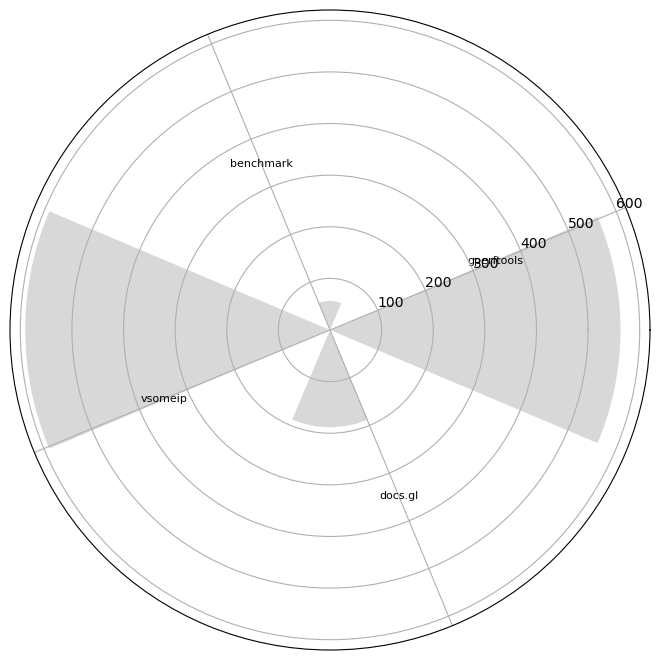

In [55]:
start_path='/home/hexu/thirdparty'
folders = build_folders(start_path)
draw(folders)

## 4.11 定制matplotlib绘图风格

In [56]:
import matplotlib

In [57]:
matplotlib.get_configdir()

'/home/hexu/.config/matplotlib'

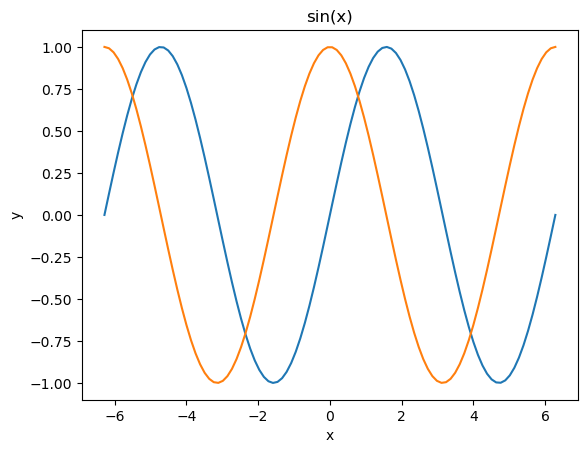

In [60]:
import matplotlib.pyplot as plt 
import matplotlib 
import numpy as np

x = np.linspace(-2*np.pi, 2*np.pi, 100)
plt.title('sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x))
plt.show()

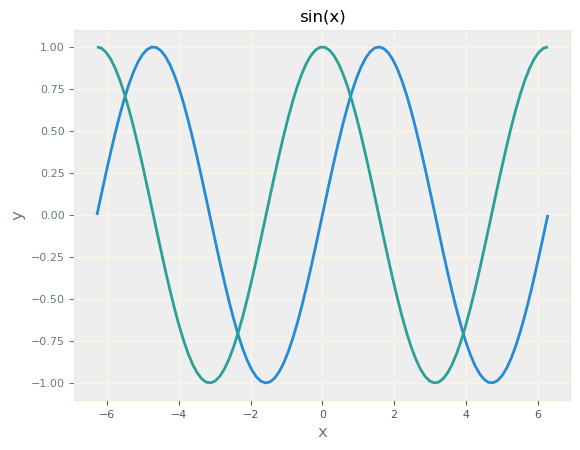

In [76]:
import matplotlib.pyplot as plt 
import matplotlib 
import numpy as np

plt.style.use('./mystyle.mplstyle') 
x = np.linspace(-2*np.pi, 2*np.pi, 100)
plt.title('sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x))
plt.show()

In [67]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [69]:
import matplotlib as mpl
print(mpl.get_configdir() + '/stylelib/')  # 通常是 ~/.matplotlib/stylelib/

/home/hexu/.config/matplotlib/stylelib/


In [75]:
plt.style.use('./mystyle.mplstyle') 